In [30]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

os.makedirs("veriseti/temiz", exist_ok=True)
os.makedirs("veriseti/sentetik", exist_ok=True)

In [31]:
def gurultu_ekle(img, sigma):
    gurultu = np.random.normal(0, sigma, img.shape).astype(np.float32)
    bozuk = img.astype(np.float32) + gurultu
    return np.clip(bozuk, 0, 255).astype(np.uint8)

def karart(img, faktor):
    return np.clip(img.astype(np.float32) * faktor, 0, 255).astype(np.uint8)

def bulanıklaştır(img, ksize):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

def karisik_bozulma(img, sigma, faktor):
    return gurultu_ekle(karart(img, faktor), sigma)

In [32]:
import random

TEKRAR = 6 
gurultu_araliklari  = {"hafif": (5, 15), "orta": (18, 32), "siddetli": (35, 55)}
karanlik_araliklari = {"hafif": (0.55, 0.75), "orta": (0.30, 0.45), "siddetli": (0.10, 0.25)}
bulanik_secenekleri = {"hafif": [3, 5], "orta": [7, 9, 11], "siddetli": [13, 15, 17, 19]}

kaynak_dosyalar = glob.glob("/veriseti/temiz/*.png") + glob.glob("veriseti/temiz/*.jpg")
print(f"{len(kaynak_dosyalar)} kaynak (temiz) fotoğraf bulundu")

kayitlar = []
sayac = 0

for kaynak_yol in kaynak_dosyalar:
    kaynak_adi = os.path.splitext(os.path.basename(kaynak_yol))[0]
    gray = cv2.cvtColor(cv2.imread(kaynak_yol), cv2.COLOR_BGR2GRAY)

    for seviye_adi in ["hafif", "orta", "siddetli"]:
        for _ in range(TEKRAR):
            sigma = random.uniform(*gurultu_araliklari[seviye_adi])
            bozuk = gurultu_ekle(gray, sigma)
            dosya = f"veriseti/sentetik/{kaynak_adi}_gurultu_{seviye_adi}_{sayac}.png"
            cv2.imwrite(dosya, bozuk)
            kayitlar.append({"dosya": dosya, "kaynak": kaynak_adi, "tur": "gurultu", "seviye": seviye_adi}); sayac += 1

            faktor = random.uniform(*karanlik_araliklari[seviye_adi])
            bozuk = karart(gray, faktor)
            dosya = f"veriseti/sentetik/{kaynak_adi}_karanlik_{seviye_adi}_{sayac}.png"
            cv2.imwrite(dosya, bozuk)
            kayitlar.append({"dosya": dosya, "kaynak": kaynak_adi, "tur": "karanlik", "seviye": seviye_adi}); sayac += 1

            ksize = random.choice(bulanik_secenekleri[seviye_adi])
            bozuk = bulanıklaştır(gray, ksize)
            dosya = f"veriseti/sentetik/{kaynak_adi}_bulanik_{seviye_adi}_{sayac}.png"
            cv2.imwrite(dosya, bozuk)
            kayitlar.append({"dosya": dosya, "kaynak": kaynak_adi, "tur": "bulanik", "seviye": seviye_adi}); sayac += 1

            bozuk = karisik_bozulma(gray, sigma, faktor)
            dosya = f"veriseti/sentetik/{kaynak_adi}_karisik_{seviye_adi}_{sayac}.png"
            cv2.imwrite(dosya, bozuk)
            kayitlar.append({"dosya": dosya, "kaynak": kaynak_adi, "tur": "karisik", "seviye": seviye_adi}); sayac += 1

    for _ in range(TEKRAR):
        dosya = f"veriseti/sentetik/{kaynak_adi}_temiz_{sayac}.png"
        cv2.imwrite(dosya, gray)
        kayitlar.append({"dosya": dosya, "kaynak": kaynak_adi, "tur": "temiz", "seviye": "yok"}); sayac += 1

df_meta = pd.DataFrame(kayitlar)
df_meta.to_csv("veriseti/metadata.csv", index=False)
print(f"Toplam {len(df_meta)} görüntü.")
print(df_meta["tur"].value_counts())

10 kaynak (temiz) fotoğraf bulundu
Toplam 780 görüntü.
tur
gurultu     180
karanlik    180
bulanik     180
karisik     180
temiz        60
Name: count, dtype: int64


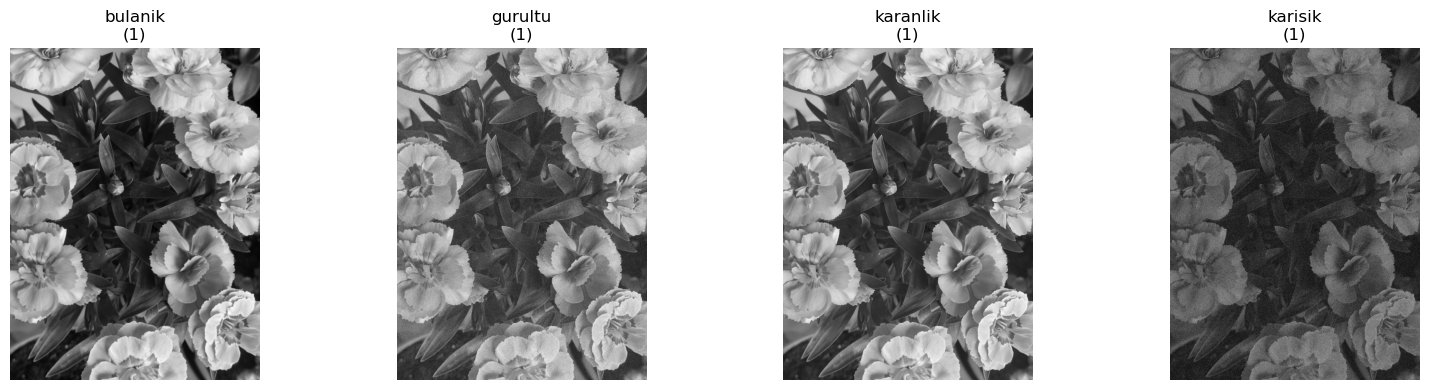

In [33]:
ornekler = df_meta[df_meta["seviye"] == "orta"].groupby("tur").first().reset_index()

fig, axes = plt.subplots(1, len(ornekler), figsize=(4 * len(ornekler), 4))
for ax, (_, row) in zip(axes, ornekler.iterrows()):
    img = cv2.imread(row["dosya"], cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['tur']}\n({row['kaynak']})")
    ax.axis("off")
plt.tight_layout()
plt.savefig("ornek_bozulmalar.png", dpi=150)
plt.show()

                                      dosya  kaynak       tur seviye  \
0   veriseti/sentetik/1_gurultu_hafif_0.png       1   gurultu  hafif   
1  veriseti/sentetik/1_karanlik_hafif_1.png       1  karanlik  hafif   
2   veriseti/sentetik/1_bulanik_hafif_2.png       1   bulanik  hafif   
3   veriseti/sentetik/1_karisik_hafif_3.png       1   karisik  hafif   
4   veriseti/sentetik/1_gurultu_hafif_4.png       1   gurultu  hafif   

   brightness   contrast   blur_score  gurultu_tahmini   entropi  siddet_skoru  
0  120.276760  54.832911  3981.314417        14.077515  7.634526           0.3  
1   89.180752  39.363156    23.401219         0.349803  6.900739           0.3  
2  120.770664  52.720292     9.429253         0.262190  7.407364           0.3  
3   88.684977  41.779118  3962.669554        14.080578  7.296901           0.3  
4  120.266666  53.840021  1812.323922         9.454342  7.542619           0.3  


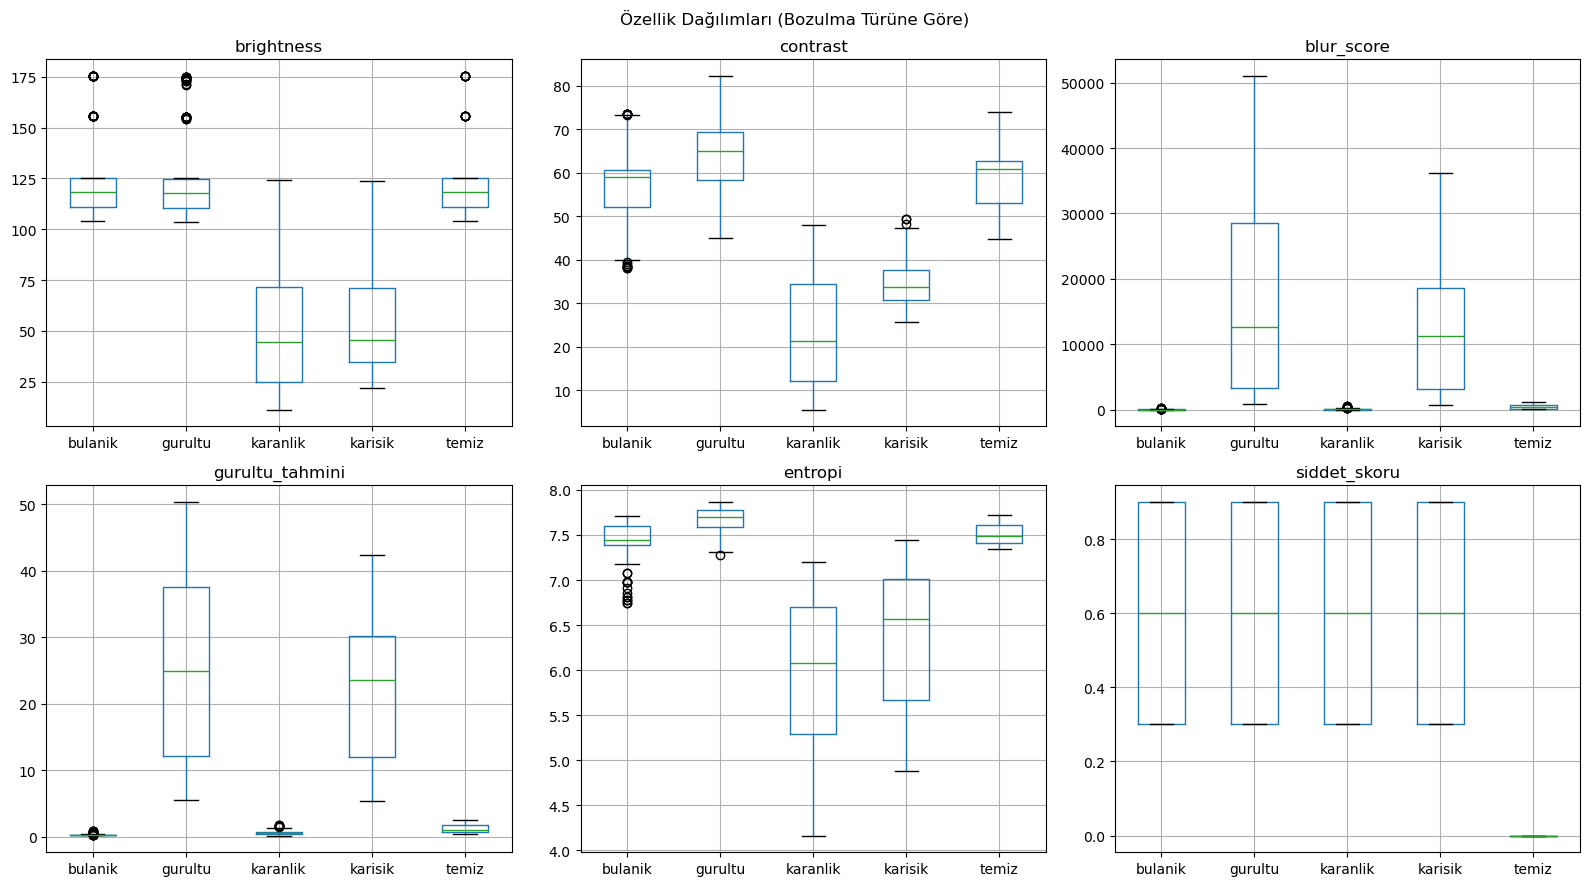

In [34]:
import pandas as pd, numpy as np, cv2, matplotlib.pyplot as plt
from skimage.measure import shannon_entropy

df = pd.read_csv("veriseti/metadata.csv")

def gurultu_tahmini(gray):
    H, W = gray.shape
    M = np.array([[1,-2,1],[-2,4,-2],[1,-2,1]], dtype=np.float64)
    conv = cv2.filter2D(gray.astype(np.float64), -1, M)
    return np.sqrt(np.pi/2) * np.sum(np.abs(conv)) / (6*(W-2)*(H-2))

def ozellik_cikar(dosya_yolu):
    img = cv2.imread(dosya_yolu, cv2.IMREAD_GRAYSCALE)
    return {
        "brightness": np.mean(img),
        "contrast": np.std(img),
        "blur_score": cv2.Laplacian(img, cv2.CV_64F).var(),
        "gurultu_tahmini": gurultu_tahmini(img),
        "entropi": shannon_entropy(img),
    }

ozellikler = df["dosya"].apply(ozellik_cikar).apply(pd.Series)
df = pd.concat([df, ozellikler], axis=1)

severity_map = {"yok": 0.0, "hafif": 0.3, "orta": 0.6, "siddetli": 0.9}
df["siddet_skoru"] = df["seviye"].map(severity_map)

df.to_csv("veriseti/ozellikler.csv", index=False)
print(df.head())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
ozellik_listesi = ["brightness","contrast","blur_score","gurultu_tahmini","entropi","siddet_skoru"]
for ax, ozellik in zip(axes.flat, ozellik_listesi):
    df.boxplot(column=ozellik, by="tur", ax=ax)
    ax.set_title(ozellik); ax.set_xlabel("")
plt.suptitle("Özellik Dağılımları (Bozulma Türüne Göre)")
plt.tight_layout()
plt.savefig("ozellik_dagilimlari.png", dpi=150)
plt.show()

===== SINIFLANDIRMA =====
              precision    recall  f1-score   support

     bulanik       1.00      1.00      1.00        45
     gurultu       1.00      1.00      1.00        45
    karanlik       1.00      1.00      1.00        45
     karisik       1.00      1.00      1.00        45
       temiz       1.00      1.00      1.00        15

    accuracy                           1.00       195
   macro avg       1.00      1.00      1.00       195
weighted avg       1.00      1.00      1.00       195



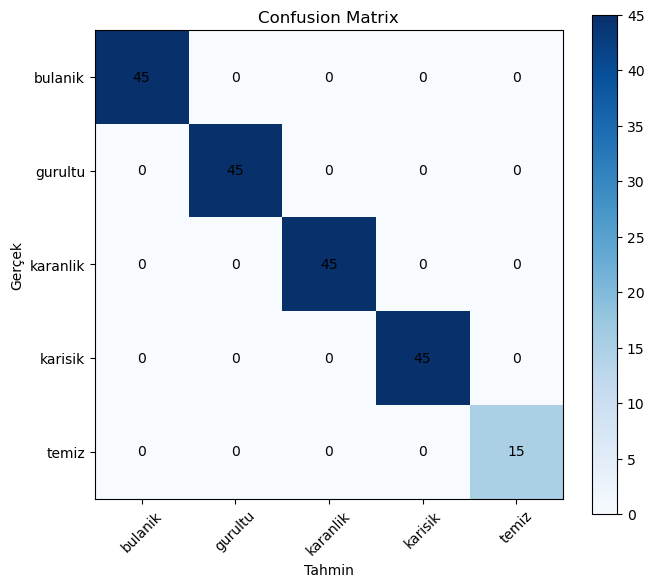


Özellik Önem Sıralaması:
 gurultu_tahmini    0.262332
brightness         0.208090
blur_score         0.201846
entropi            0.182828
contrast           0.144904
dtype: float64

===== REGRESYON ===== 
MAE: 0.0096   R²: 0.9930


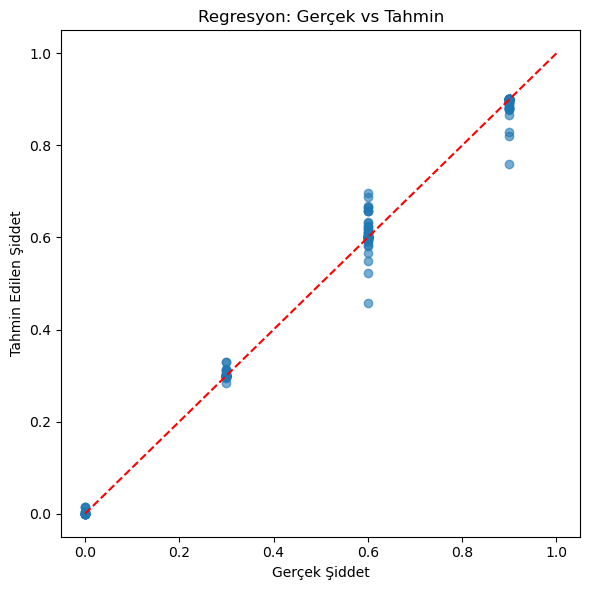

['regresyon_modeli.pkl']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score
import joblib

df = pd.read_csv("veriseti/ozellikler.csv")
ozellik_kolonlari = ["brightness","contrast","blur_score","gurultu_tahmini","entropi"]
X = df[ozellik_kolonlari]

y_tur = df["tur"]
X_train, X_test, y_train, y_test = train_test_split(X, y_tur, test_size=0.25, random_state=42, stratify=y_tur)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("===== SINIFLANDIRMA =====")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(clf.classes_))); ax.set_xticklabels(clf.classes_, rotation=45)
ax.set_yticks(range(len(clf.classes_))); ax.set_yticklabels(clf.classes_)
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
for i in range(len(clf.classes_)):
    for j in range(len(clf.classes_)):
        ax.text(j, i, cm[i,j], ha="center", va="center")
plt.colorbar(im); plt.title("Confusion Matrix"); plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150); plt.show()

onem = pd.Series(clf.feature_importances_, index=ozellik_kolonlari).sort_values(ascending=False)
print("\nÖzellik Önem Sıralaması:\n", onem)

y_siddet = df["siddet_skoru"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y_siddet, test_size=0.25, random_state=42)

reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

print(f"\n===== REGRESYON ===== \nMAE: {mean_absolute_error(yr_test, yr_pred):.4f}   R²: {r2_score(yr_test, yr_pred):.4f}")

plt.figure(figsize=(6,6))
plt.scatter(yr_test, yr_pred, alpha=0.6)
plt.plot([0,1],[0,1],"r--")
plt.xlabel("Gerçek Şiddet"); plt.ylabel("Tahmin Edilen Şiddet")
plt.title("Regresyon: Gerçek vs Tahmin")
plt.tight_layout(); plt.savefig("regresyon_sonuc.png", dpi=150); plt.show()

joblib.dump(clf, "siniflandirma_modeli.pkl")
joblib.dump(reg, "regresyon_modeli.pkl")

In [43]:
clf = joblib.load("siniflandirma_modeli.pkl")
reg = joblib.load("regresyon_modeli.pkl")

def unsharp_mask(img, sigma=1.0, amount=1.0):
    bulanik = cv2.GaussianBlur(img, (0,0), sigma)
    return cv2.addWeighted(img, 1+amount, bulanik, -amount, 0)

def gurultu_giderme_pipeline(gray_img, h=25, sharpen_amount=1.0, sharpen_sigma=1.0):
    denoised = cv2.fastNlMeansDenoising(gray_img, None, h=h, templateWindowSize=7, searchWindowSize=21)
    return unsharp_mask(denoised, sharpen_sigma, sharpen_amount)

def karanlik_iyilestirme_pipeline(gray_img, clip_limit=25, tile_size=(8,8), denoise_h=7):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return cv2.fastNlMeansDenoising(clahe.apply(gray_img), None, h=denoise_h)

def bulaniklik_giderme_pipeline(gray_img, amount=1.5):
    return unsharp_mask(gray_img, sigma=1.0, amount=amount)

def akilli_onarim(dosya_yolu):
    gray = cv2.imread(dosya_yolu, cv2.IMREAD_GRAYSCALE)
    ozellik = ozellik_cikar(dosya_yolu)
    X_yeni = pd.DataFrame([ozellik])[ozellik_kolonlari]

    tur = clf.predict(X_yeni)[0]
    siddet = reg.predict(X_yeni)[0]
    print(f"Teşhis: {tur}  |  Tahmini şiddet: {siddet:.2f}")

    if tur == "gurultu":
        return gurultu_giderme_pipeline(gray, h=int(5 + siddet*60)), tur, siddet
    elif tur == "karanlik":
        return karanlik_iyilestirme_pipeline(gray, clip_limit=2 + siddet*28), tur, siddet
    elif tur == "karisik":
        ara = karanlik_iyilestirme_pipeline(gray, clip_limit=2 + siddet*28)
        return gurultu_giderme_pipeline(ara, h=int(5 + siddet*40)), tur, siddet
    elif tur == "bulanik":
        return bulaniklik_giderme_pipeline(gray, amount=0.5 + siddet*2.0), tur, siddet
    else: 
        return gray, tur, siddet

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

test_ciftleri = [
    ("fotograflar/gurultulu_foto.jpg", "fotograflar/gurultulu_referans.jpg"),
    ("fotograflar/karanlik_foto2.jpg", "fotograflar/karanlik_referans.jpg"),
]

for test_dosya, referans_dosya in test_ciftleri:
    onarilmis, tur, siddet = akilli_onarim(test_dosya)
    ref = cv2.imread(referans_dosya, cv2.IMREAD_GRAYSCALE)
    ref = cv2.resize(ref, (onarilmis.shape[1], onarilmis.shape[0]))
    print(f"{test_dosya}\n  PSNR: {psnr(ref, onarilmis):.2f} dB   SSIM: {ssim(ref, onarilmis):.4f}\n")

Teşhis: temiz  |  Tahmini şiddet: 0.00
fotograflar/gurultulu_foto.jpg
  PSNR: 21.70 dB   SSIM: 0.4001

Teşhis: karanlik  |  Tahmini şiddet: 0.88
fotograflar/karanlik_foto2.jpg
  PSNR: 18.46 dB   SSIM: 0.5554



In [41]:
print("gurultulu_foto.jpg özellikleri:")
print(ozellik_cikar("fotograflar/gurultulu_foto.jpg"))
print("\nEğitim setinde 'temiz' sınıfı ortalaması:")
print(df[df["tur"]=="temiz"][ozellik_kolonlari].mean())
print("\nEğitim setinde 'gurultu' sınıfı ortalaması:")
print(df[df["tur"]=="gurultu"][ozellik_kolonlari].mean())

gurultulu_foto.jpg özellikleri:
{'brightness': np.float64(129.07060273784572), 'contrast': np.float64(72.49719949656242), 'blur_score': np.float64(268.51006964108), 'gurultu_tahmini': np.float64(0.9228981342166732), 'entropi': np.float64(7.521606057360585)}

Eğitim setinde 'temiz' sınıfı ortalaması:
brightness         125.023580
contrast            58.701906
blur_score         449.571046
gurultu_tahmini      1.254132
entropi              7.519141
dtype: float64

Eğitim setinde 'gurultu' sınıfı ortalaması:
brightness           124.625526
contrast              64.124948
blur_score         17009.339258
gurultu_tahmini       25.592898
entropi                7.672090
dtype: float64
